In [2]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


# Function to construct quak spaces

In [3]:
def makeQuakSpace(bkg_axes,sig_axes,baseDir):
    from sklearn.decomposition import PCA
    
    axes = sig_axes+bkg_axes
    spaceName = "-".join(bkg_axes+sig_axes)
    if not os.path.isdir(baseDir+"/quakSpaces/"+spaceName):
        os.mkdir(baseDir+"/quakSpaces/"+spaceName)
    outDir = baseDir+"/quakSpaces/"+spaceName+"/"
    
    # loading some bkg files for the PCA
    data_dict = {axName:[] for axName in axes}
    masses = []
    for i in range(3):
        fName = baseDir+"/nominal/eval_QCDBKG_{0}.h5".format(i)
        with h5py.File(fName,"r") as f:
            for axName in axes:
                data_dict[axName].append(f[axName][()])
            masses.append(f["mass"][()])
    data_dict = {axName:np.concatenate(data_dict[axName],axis=0) for axName in list(data_dict.keys())}
    masses = np.concatenate(masses,axis=0)
    combined = [masses[:,np.newaxis]] + [data_dict[axName][:,np.newaxis] for axName in axes]
    combined = np.concatenate(combined,axis=1)
    
    # doing the PCA
    pcas = {}
    for axName in axes:
        pca = PCA()
        toFit = np.concatenate((masses[:,np.newaxis],data_dict[axName][:,np.newaxis]),axis=1)
        pca = pca.fit(toFit)
        pcas[axName] = pca
    #pca = PCA()
    #pca = pca.fit(combined)
    
    # cleanup
    del data_dict, masses, combined
    
    # apply PCA to all the files
    for file in [ff for ff in os.listdir(baseDir+"/nominal/") if ".h5" in ff]:
        fName = baseDir+"/nominal/"+file
        with h5py.File(fName,"r") as f:
            mass = f["mass"][()][:,np.newaxis]
            transformed_dict = {}
            for axName in axes:
                toTransform = np.concatenate((mass,f[axName][()][:,np.newaxis]),axis=1)
                pca = pcas[axName]
                transformed = np.dot(toTransform,pca.components_.T)
                transformed_dict[axName] = transformed[:,1]
            #combined = [f[axName][()][:,np.newaxis] for axName in axesWithMass]
            #combined = np.concatenate(combined,axis=1)
            #transformed = pca.transform(combined)
            with h5py.File(outDir+file,"w") as of:
                of.create_dataset("mass",data=mass)
                #for i in range(len(axesWithMass)):
                #    if axesWithMass[i] != "mass":
                #        of.create_dataset(axesWithMass[i],data=transformed[:,i])
                for axName in axes:
                    of.create_dataset(axName,data=transformed_dict[axName])
    return outDir

In [4]:
import corner
import matplotlib.lines as mlines
import matplotlib as mpl
def makeCornerPlots(directory,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs,nBins=50,lossCut=100,quantile=0.01):
    axes = bkg_axes+sig_axes
    axNames = bkg_axNames+sig_axNames
    ndim = len(axes)
    bkg_data = []
    for i in range(3):
        with h5py.File(outDir+"eval_QCDBKG_{0}.h5".format(i),"r") as f:
            data = []
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            data = data[np.all(np.abs(data) < lossCut,axis=1)]
            bkg_data.append(data)
    bkg_data = np.concatenate(bkg_data,axis=0)
    
    sig_data = []
    for sig in sigs:
        with h5py.File(outDir+"eval_{0}.h5".format(sig),"r") as f:
            data = []
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            data = data[np.all(np.abs(data) < lossCut,axis=1)]
            sig_data.append(data)
    
    datas = [bkg_data] + sig_data
    leftLims, rightLims = [],[]
    for dat in datas:
        leftLims.append(np.quantile(dat,quantile/2,axis=0).reshape(1,-1))
        rightLims.append(np.quantile(dat,1-quantile/2,axis=0).reshape(1,-1))
    leftLims = np.concatenate(leftLims,axis=0)
    rightLims = np.concatenate(rightLims,axis=0)
    leftLims = np.min(leftLims,axis=0)
    rightLims = np.max(rightLims,axis=0)
    lossRanges = [[leftLims[i],rightLims[i]] for i in range(len(leftLims))]
    print(lossRanges)
    labels = ["QCD MC"] + sigs
    fig,axes = plt.subplots(ndim,ndim,figsize=(8,8))
    plt.tight_layout()
    lines = []
    for i,d in enumerate(datas):
        b = corner.corner(
            datas[i],
            quantiles=[0.99],
            fig=fig,
            color='C{0}'.format(i),
            hist_kwargs={'density':True},
            contour_kwargs={"levels":[20]},
            labels=axNames,
            labelpad=0.0,
            label_kwargs={'fontsize':14},
            bins=[nBins for i in range(len(axes))],
            plot_datapoints=False,
            plot_density=True,
            fill_contours=False,
            no_fill_contours=True,
            range=lossRanges,
            data_kwargs={"alpha":0.5}
        )
        lines.append(mlines.Line2D([], [], color='C{0}'.format(i), label=labels[i]))
    plt.legend(handles=lines,loc=4,bbox_to_anchor=(0., 1.0, 1., .0))
    plt.tight_layout()
    plt.savefig(outDir+"corner_plot.pdf")

# Making dataSB-training quak spaces (2017)

In [4]:
year = 2017
baseDir="evaluations/dataSB_massFlat/{0}".format(year)
Path(baseDir+"/quakSpaces").mkdir(exist_ok=True)

[[0.1093894624710083, 38.80666927337643], [1.0977819347381592, 90.52139869689941]]


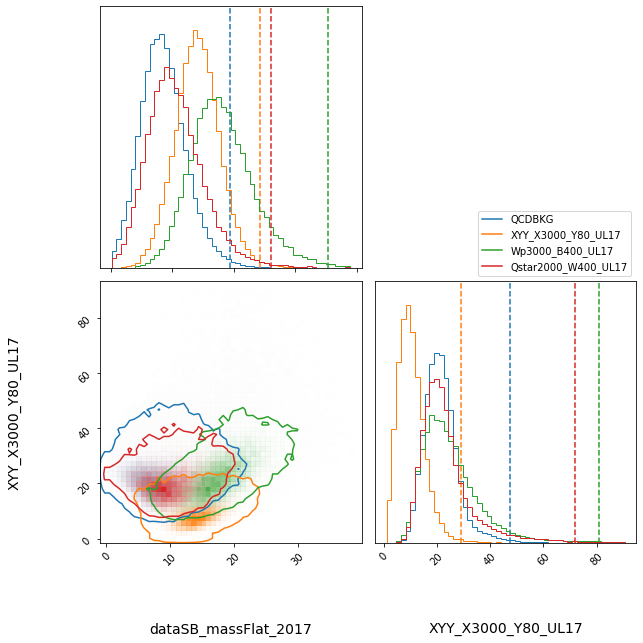

In [5]:
sig_axes = ['XYY_X3000_Y80_UL17']
bkg_axes = ['dataSB_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.10893849227577448, 90.88068950653079], [3.094409074783325, 92.04395729064954]]


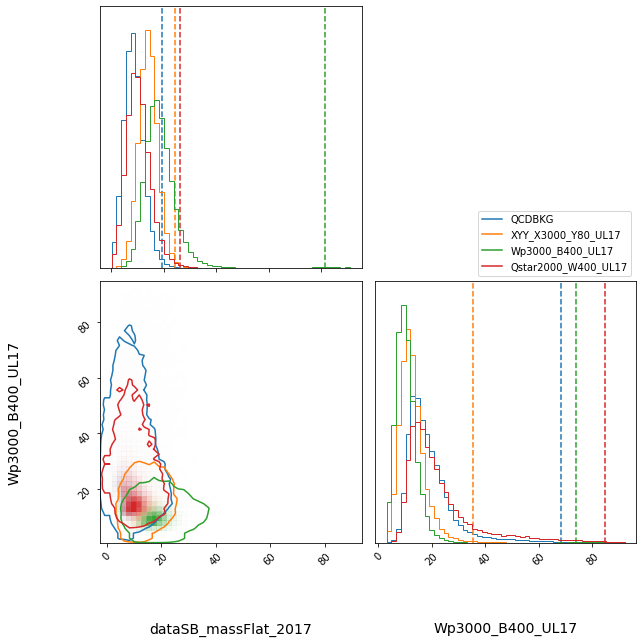

In [6]:
sig_axes = ['Wp3000_B400_UL17']
bkg_axes = ['dataSB_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.11351394984871163, 69.45471069335979], [6.403191981315613, 77.13408401489289]]


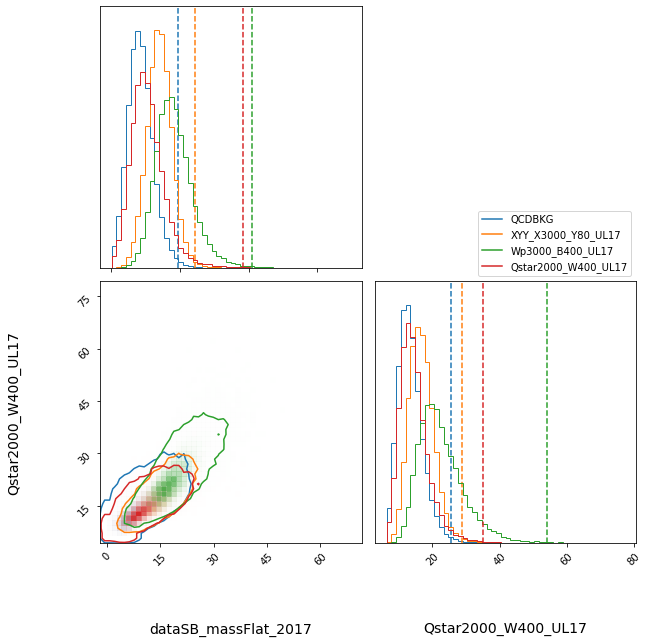

In [7]:
sig_axes = ['Qstar2000_W400_UL17']
bkg_axes = ['dataSB_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.10890421766787768, 38.80674179077151], [1.0966570597887038, 90.52140075683593], [3.078488674163818, 90.64515144348131]]


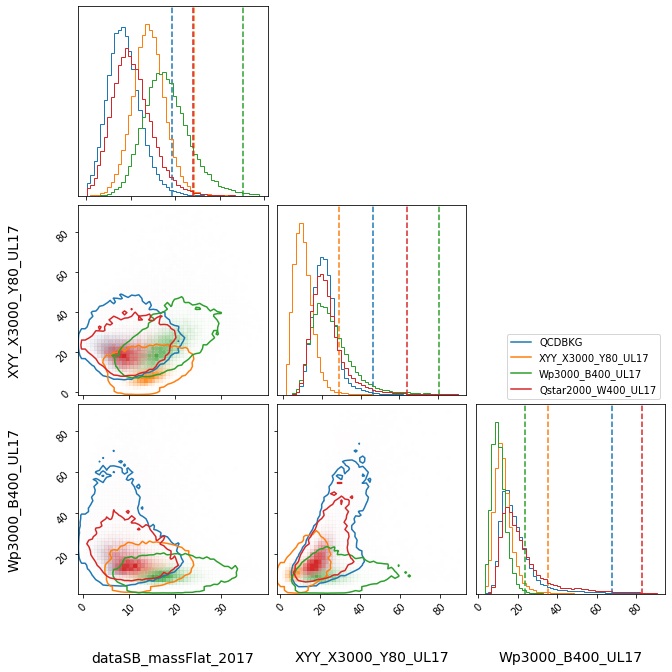

In [8]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['dataSB_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.1093894624710083, 38.80666927337643], [1.0977557748556137, 90.52139869689941], [6.401368827819825, 48.59982303619374]]


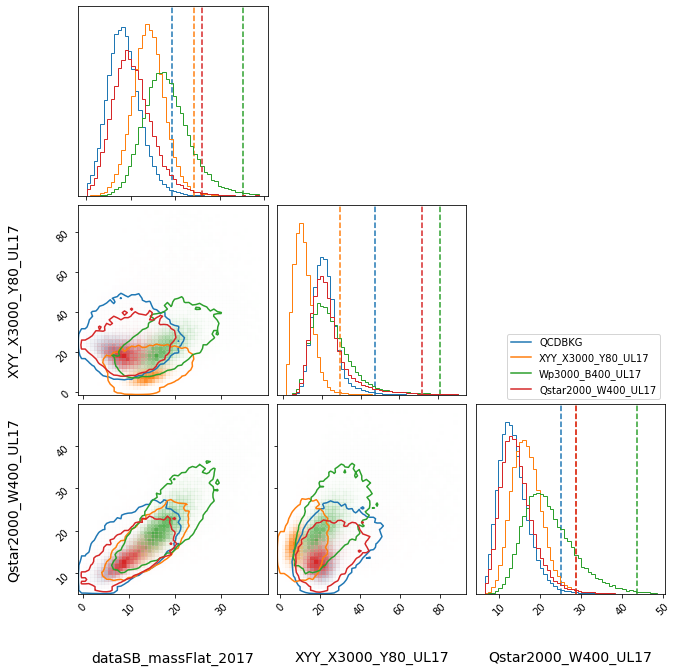

In [9]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.10893563605844975, 58.362965087890345], [3.090835485458374, 91.64052047729487], [6.4003586769104, 75.66043060302675]]


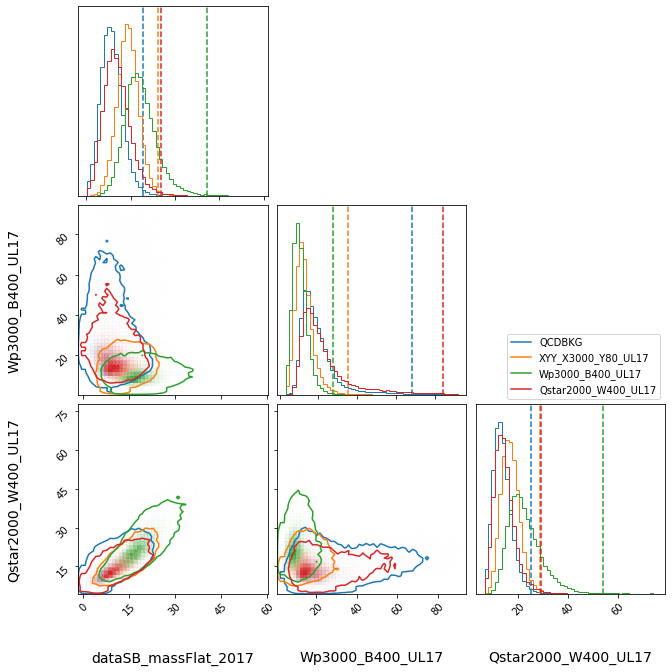

In [10]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.10890421766787768, 38.80674179077151], [1.0966308999061585, 90.52140075683593], [3.078488674163818, 90.64515144348131], [6.400064945220947, 48.600027160644615]]


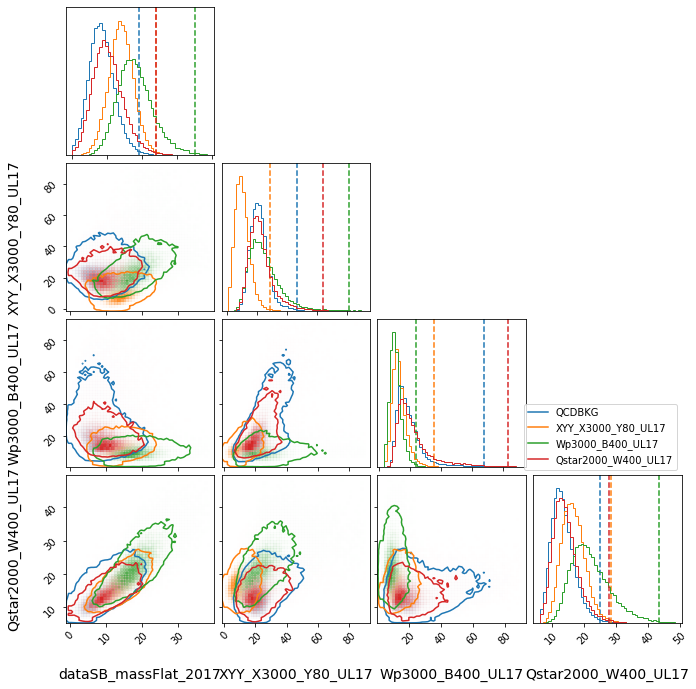

In [11]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Making QCDBKG (MC) quak spaces

In [4]:
year = 2017
baseDir="evaluations/qcdbkg_massFlat/{0}".format(year)
Path(baseDir+"/quakSpaces").mkdir(exist_ok=True)

### 1. Training Signals

[[1.1682477807998657, 29.38976098060605], [-1.108902611732483, 79.50193267822281]]


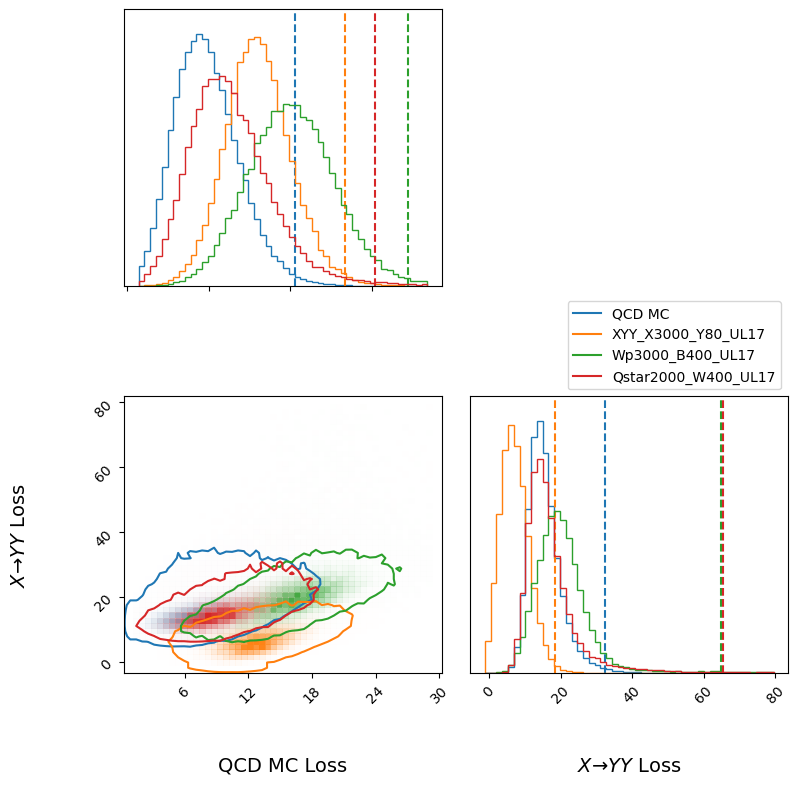

In [33]:
sig_axes = ['XYY_X3000_Y80_UL17']
sig_axNames = [r"$X \to YY$ Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

[[1.168099301457405, 30.96609439849852], [1.134607722759247, 89.43091358184815]]


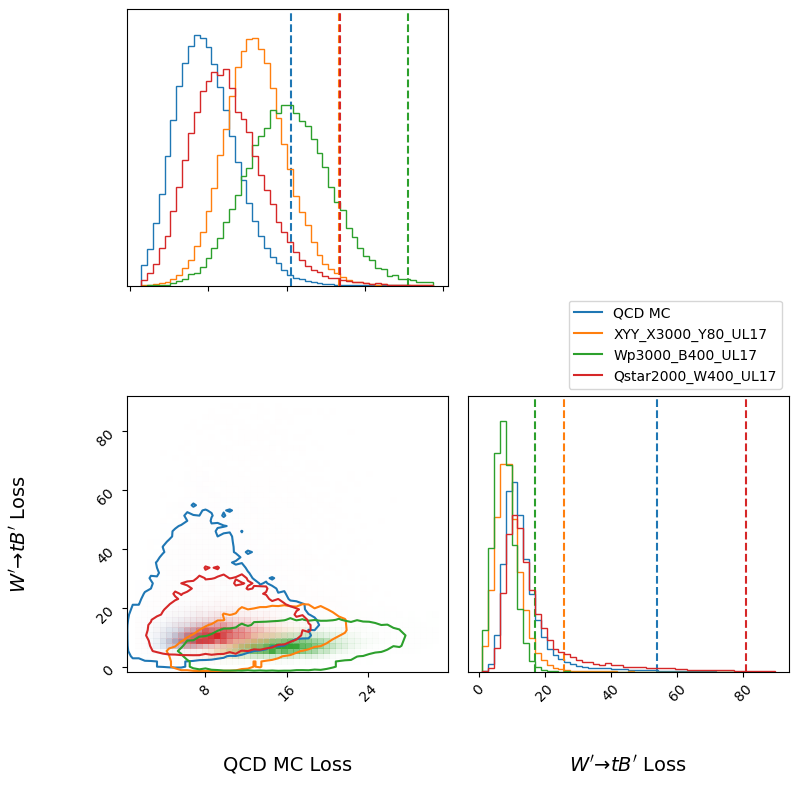

In [35]:
sig_axes = ['Wp3000_B400_UL17']
sig_axNames = [r"$W^\prime \to tB^\prime$ Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

[[1.16829654276371, 43.76975589752212], [2.0268099308013916, 34.72521556854242]]


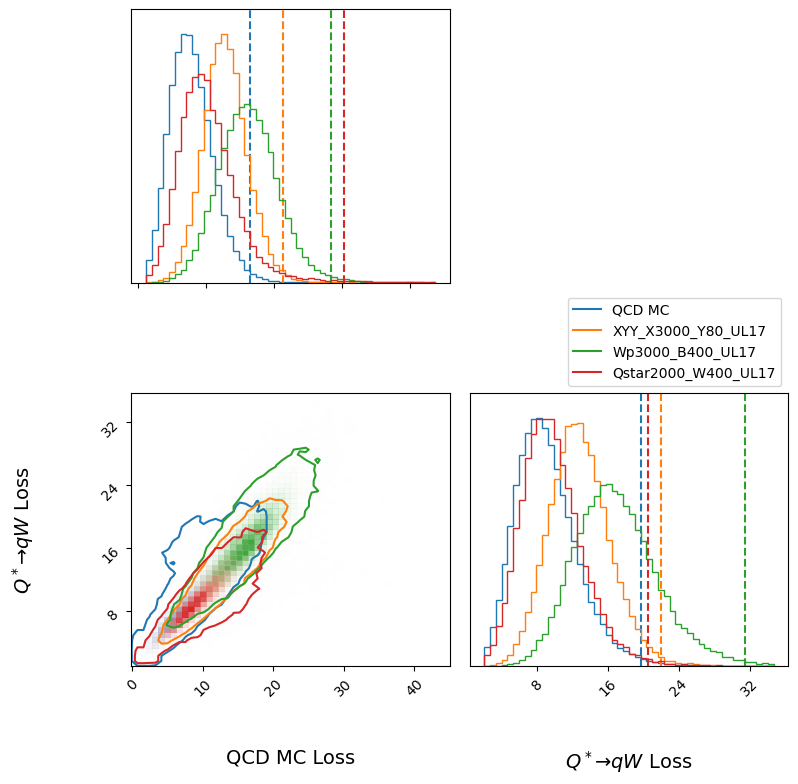

In [36]:
sig_axes = ['Qstar2000_W400_UL17']
sig_axNames = [r"$Q^* \to qW$ Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

[[1.16829654276371, 43.76975589752212], [-0.3912632985413074, 21.305919609069836]]


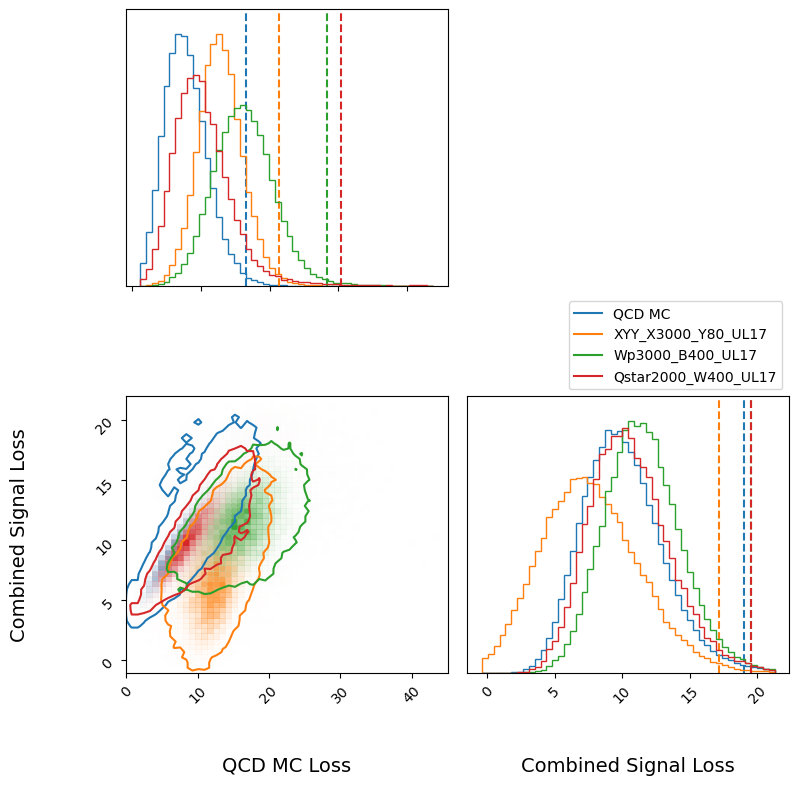

In [37]:
sig_axes = ['Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17']
sig_axNames = ["Combined Signal Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

### 2. Extra (non-training) signals

[[1.1682477807998657, 46.13817024230957], [3.563199087381363, 85.14359664916992]]


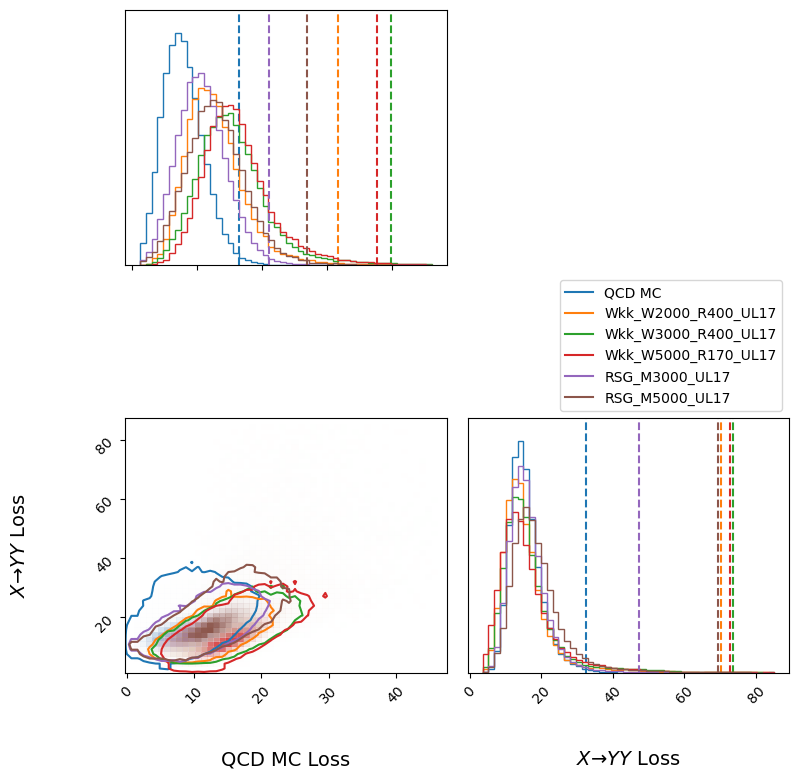

In [5]:
sig_axes = ['XYY_X3000_Y80_UL17']
sig_axNames = [r"$X \to YY$ Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ["Wkk_W2000_R400_UL17","Wkk_W3000_R400_UL17","Wkk_W5000_R170_UL17","RSG_M3000_UL17","RSG_M5000_UL17"]
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

[[1.168099301457405, 45.31661384582521], [-1.3329283624887467, 88.39422336578372]]


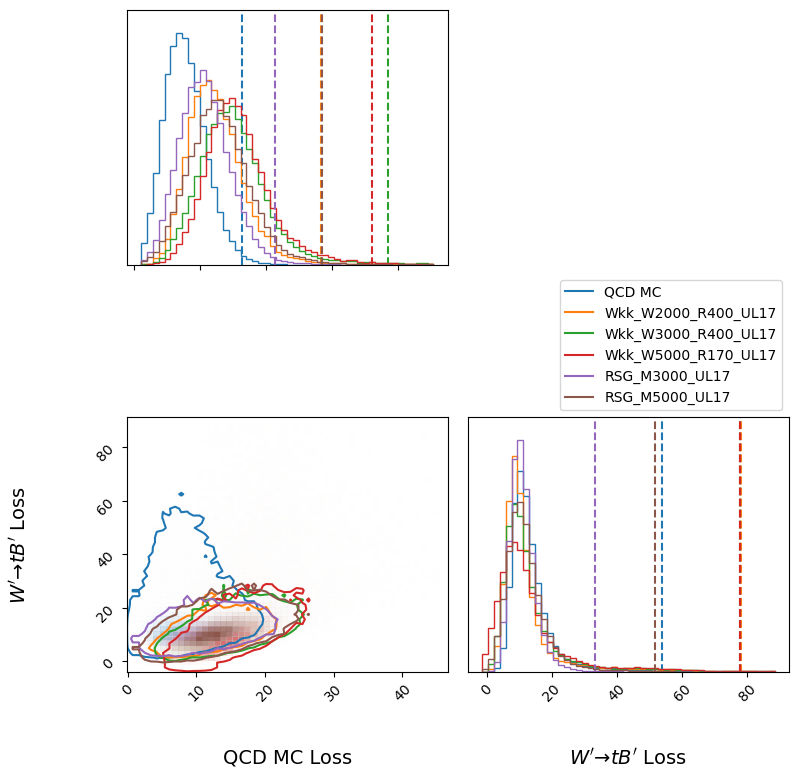

In [6]:
sig_axes = ['Wp3000_B400_UL17']
sig_axNames = [r"$W^\prime \to tB^\prime$ Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ["Wkk_W2000_R400_UL17","Wkk_W3000_R400_UL17","Wkk_W5000_R170_UL17","RSG_M3000_UL17","RSG_M5000_UL17"]
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

[[1.16829654276371, 58.68465091705301], [2.0268099308013916, 55.8755012512208]]


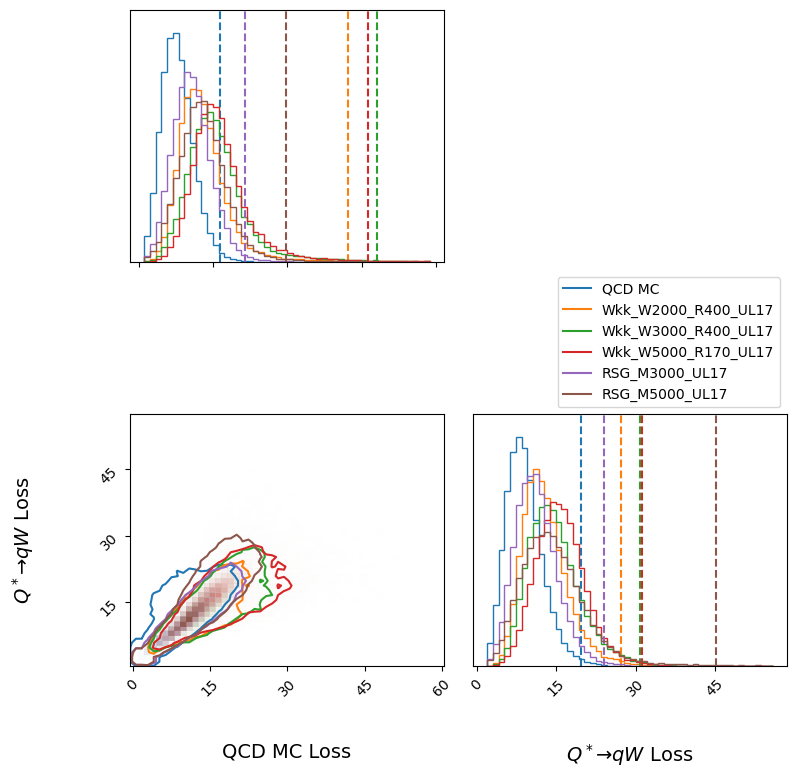

In [7]:
sig_axes = ['Qstar2000_W400_UL17']
sig_axNames = [r"$Q^* \to qW$ Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ["Wkk_W2000_R400_UL17","Wkk_W3000_R400_UL17","Wkk_W5000_R170_UL17","RSG_M3000_UL17","RSG_M5000_UL17"]
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

[[1.16829654276371, 59.18726631164547], [3.7370653128623963, 41.455671997070304]]


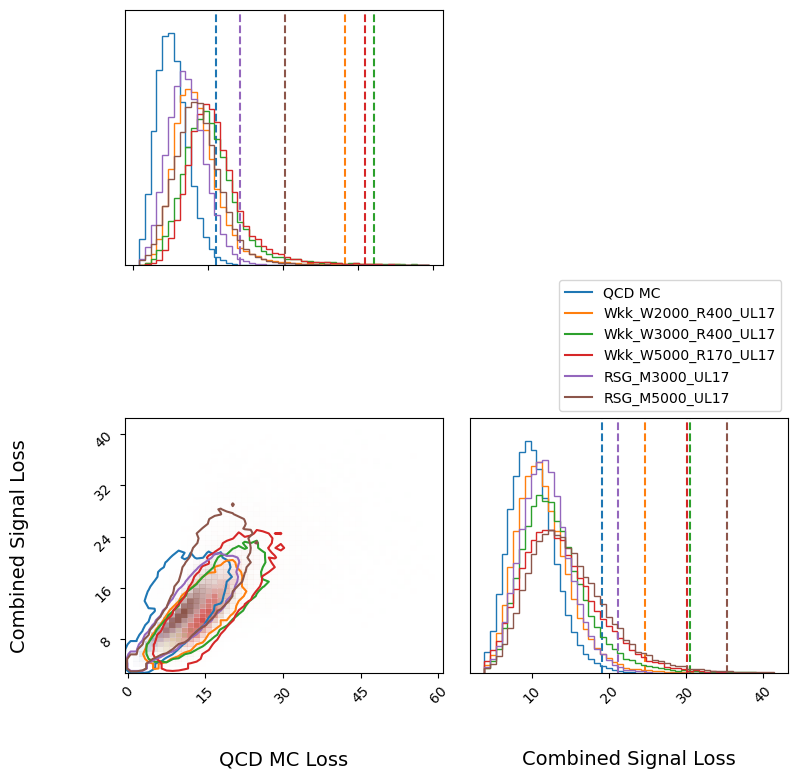

In [8]:
sig_axes = ['Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17']
sig_axNames = ["Combined Signal Loss"]
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
bkg_axNames = ["QCD MC Loss"]
sigs = ["Wkk_W2000_R400_UL17","Wkk_W3000_R400_UL17","Wkk_W5000_R170_UL17","RSG_M3000_UL17","RSG_M5000_UL17"]
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,bkg_axNames,sig_axNames,sigs)

### 3. >2D QUAK Spaces

[[-1.8719647985696795, 37.02588382720947], [-0.20855538733303544, 89.49360649108881], [3.950302692651748, 91.58861198425294]]


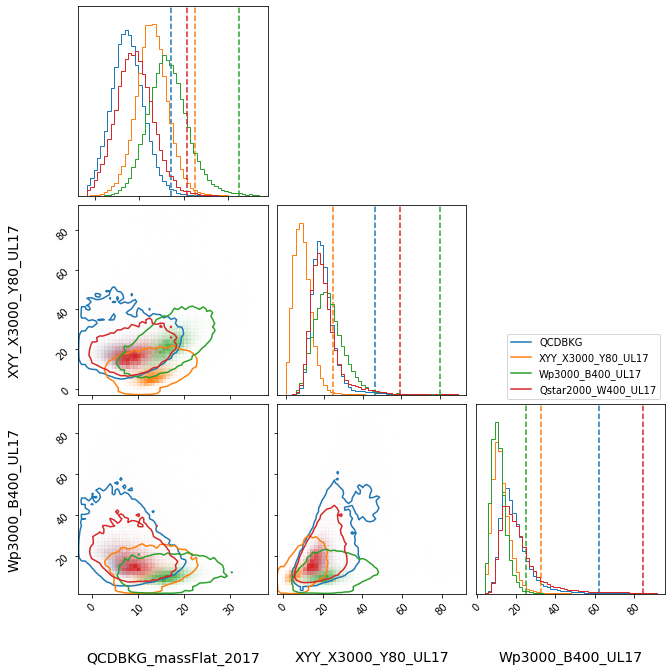

In [16]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.8692852598428726, 36.70552648544312], [-0.20780150920152662, 89.13564373016362], [5.4655899453163155, 62.041283512115506]]


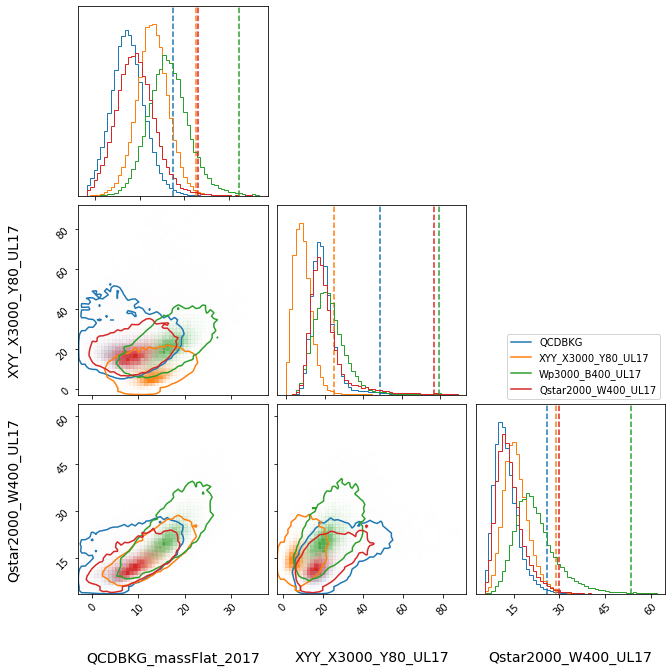

In [17]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.8718152183294294, 46.95118431091303], [3.9584466314315794, 91.85315658569336], [5.463382651805878, 75.62072029113767]]


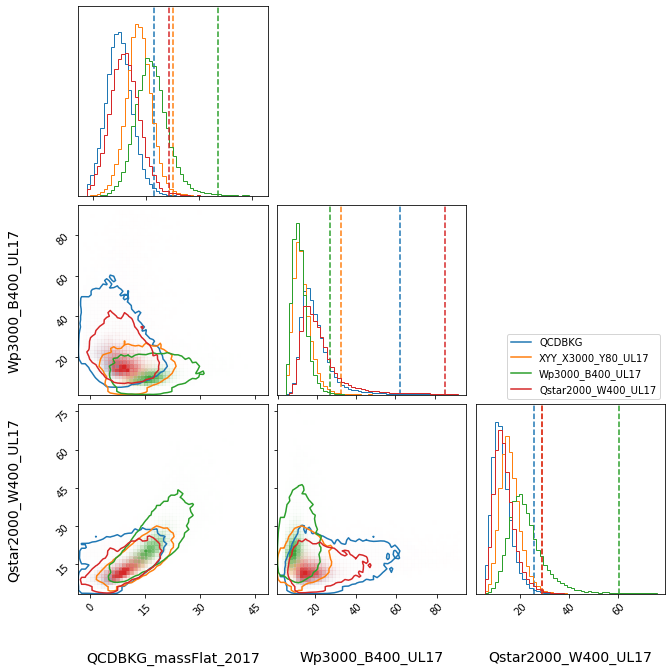

In [18]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[-1.8719691979885102, 36.692570953369106], [-0.20859156362712378, 89.08112285614011], [3.9500576603412627, 91.58861198425294], [5.4633773946762085, 62.03160360336303]]


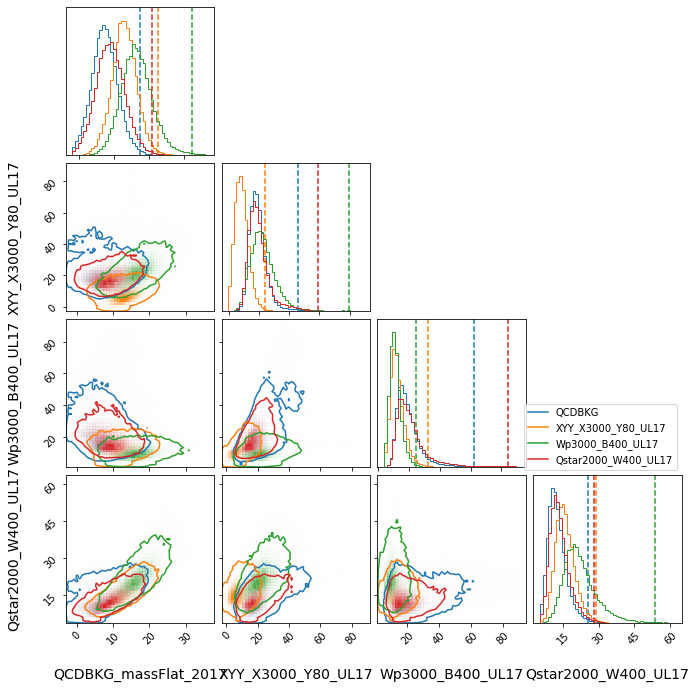

In [19]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_massFlat_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Make Normal Quak Space Scatter Plots

In [5]:
def makeScatterPlot(directory,bkg_axis,sig_axis,bkg_axName,sig_axName,sigs,ax,qx=0.99,qy=0.99,nmax=10000):
    bkg_data = []
    for i in range(3):
        with h5py.File(outDir+"eval_QCDBKG_{0}.h5".format(i),"r") as f:
            data = []
            data.append(f[bkg_axis][()][:,np.newaxis])
            data.append(f[sig_axis][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            bkg_data.append(data)
    bkg_data = np.concatenate(bkg_data,axis=0)
    
    sig_data = []
    for sig in sigs:
        with h5py.File(outDir+"eval_{0}.h5".format(sig),"r") as f:
            data = []
            data.append(f[bkg_axis][()][:,np.newaxis])
            data.append(f[sig_axis][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            sig_data.append(data)
    
    xmax = np.max([np.quantile(bkg_data[:,0],qx)]+[np.quantile(s[:,0],qx) for s in sig_data])
    ymax = np.max([np.quantile(bkg_data[:,1],qy)]+[np.quantile(s[:,1],qy) for s in sig_data])
    
    ax.scatter(bkg_data[:nmax,0],bkg_data[:nmax,1],label="QCD MC",s=2)
    for i,s in enumerate(sigs):
        ax.scatter(sig_data[i][:nmax,0],sig_data[i][:nmax,1],label=sigs[i],s=2)
    ax.legend(loc='upper right',fontsize=14)
    plt.xlim([0,xmax])
    plt.ylim([0,ymax])
    plt.xlabel(bkg_axName,fontsize=14)
    plt.ylabel(sig_axName,fontsize=14)

In [6]:
def makeContourPlot(directory,bkg_axis,sig_axis,bkg_axName,sig_axName,sigs,ax,xmax=50,ymax=50,level=10):
    bkg_data = []
    for i in range(3):
        with h5py.File(outDir+"eval_QCDBKG_{0}.h5".format(i),"r") as f:
            data = []
            data.append(f[bkg_axis][()][:,np.newaxis])
            data.append(f[sig_axis][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            bkg_data.append(data)
    bkg_data = np.concatenate(bkg_data,axis=0)
    
    sig_data = []
    for sig in sigs:
        with h5py.File(outDir+"eval_{0}.h5".format(sig),"r") as f:
            data = []
            data.append(f[bkg_axis][()][:,np.newaxis])
            data.append(f[sig_axis][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            sig_data.append(data)
    
    bx = np.linspace(0,xmax,num=100)
    by = np.linspace(0,ymax,num=100)
    lines = []
    
    c1,x1,y1 = np.histogram2d(bkg_data[:,0],bkg_data[:,1],bins=[bx,by])
    x,y = np.meshgrid((x1[1:]+x1[:-1])/2,(y1[1:]+y1[:-1])/2)
    plt.contour(x,y,c1.T,[level],colors=["C0"])
    lines.append(mlines.Line2D([], [], color='C0', label="QCD MC"))
    for i,s in enumerate(sigs):
        c1,x1,y1 = np.histogram2d(sig_data[i][:,0],sig_data[i][:,1],bins=[bx,by])
        x,y = np.meshgrid((x1[1:]+x1[:-1])/2,(y1[1:]+y1[:-1])/2)
        plt.contour(x,y,c1.T,[level],colors=["C{0}".format(i+1)])
        lines.append(mlines.Line2D([], [], color='C{0}'.format(i+1), label=sigs[i]))
        
    ax.legend(handles=lines,loc='upper right',fontsize=14)
    plt.xlim([0,xmax])
    plt.ylim([0,ymax])
    plt.xlabel(bkg_axName,fontsize=14)
    plt.ylabel(sig_axName,fontsize=14)

(0.0, 30.0)

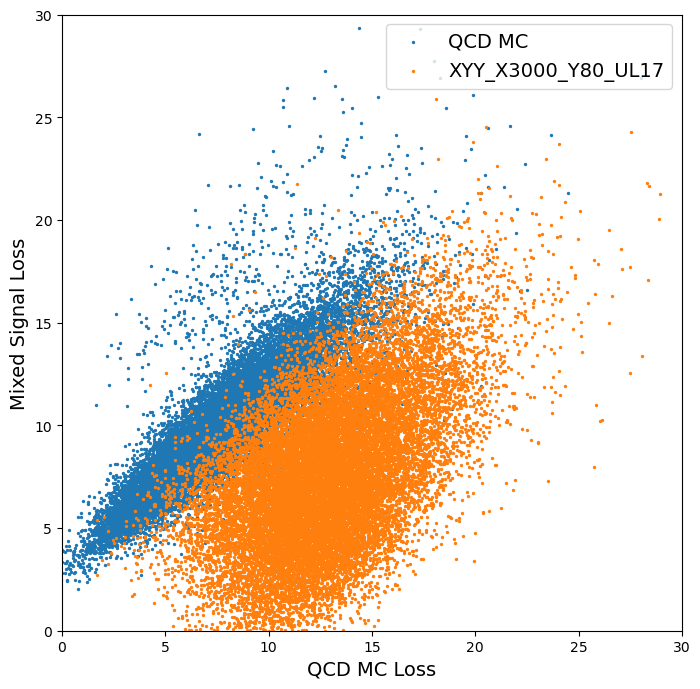

In [7]:
year=2017
sig_axis = 'Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17'
sig_axName = "Mixed Signal Loss"
bkg_axis = 'QCDBKG_massFlat_{0}'.format(year)
bkg_axName = "QCD MC Loss"
sigs = ['XYY_X3000_Y80_UL17']
outDir = "evaluations/qcdbkg_massFlat/2017/quakSpaces/QCDBKG_massFlat_2017-Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17/"
plt.figure(figsize=(8,8))
makeScatterPlot(outDir,bkg_axis,sig_axis,bkg_axName,sig_axName,sigs,plt.gca(),qx=0.999,qy=0.999,nmax=20000)
plt.xlim([0,30])
plt.ylim([0,30])
#plt.savefig(outDir+'scatter_plot.pdf')

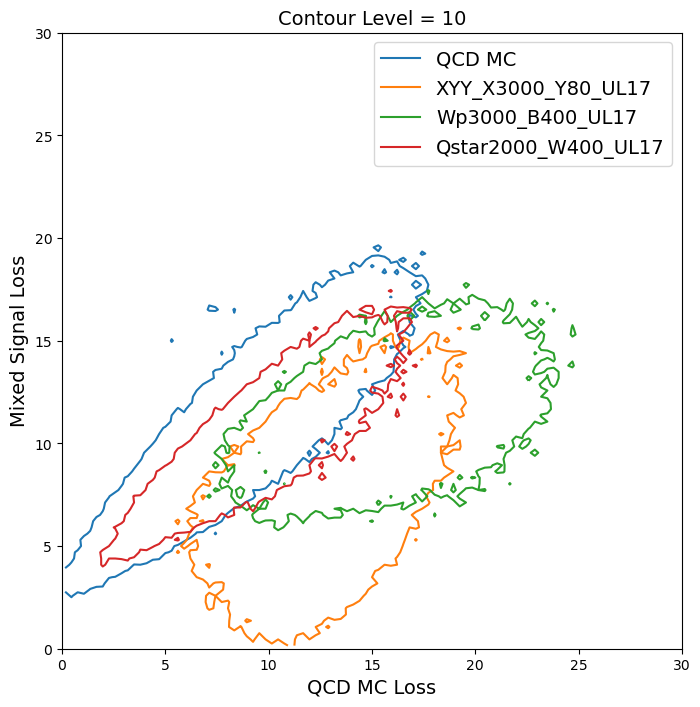

In [105]:
sig_axis = 'Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17'
sig_axName = "Mixed Signal Loss"
bkg_axis = 'QCDBKG_massFlat_{0}'.format(year)
bkg_axName = "QCD MC Loss"
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = "evaluations/qcdbkg_massFlat/2017/quakSpaces/QCDBKG_massFlat_2017-Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17/"
plt.figure(figsize=(8,8))
makeContourPlot(outDir,bkg_axis,sig_axis,bkg_axName,sig_axName,sigs,plt.gca(),xmax=30,ymax=30)
plt.title("Contour Level = 10",fontsize=14)
plt.savefig(outDir+"contour_plot.pdf")

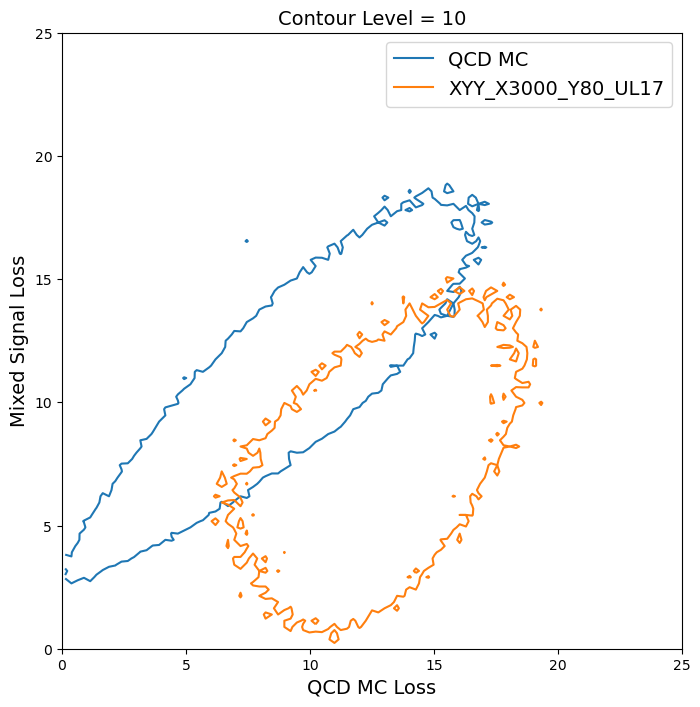

In [107]:
sig_axis = 'Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17'
sig_axName = "Mixed Signal Loss"
bkg_axis = 'QCDBKG_massFlat_{0}'.format(year)
bkg_axName = "QCD MC Loss"
sigs = ['XYY_X3000_Y80_UL17']
outDir = "evaluations/qcdbkg_massFlat/2017/quakSpaces/QCDBKG_massFlat_2017-Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17/"
plt.figure(figsize=(8,8))
makeContourPlot(outDir,bkg_axis,sig_axis,bkg_axName,sig_axName,sigs,plt.gca(),xmax=25,ymax=25)
plt.title("Contour Level = 10",fontsize=14)
plt.savefig(outDir+"contour_plot_XYY.pdf")

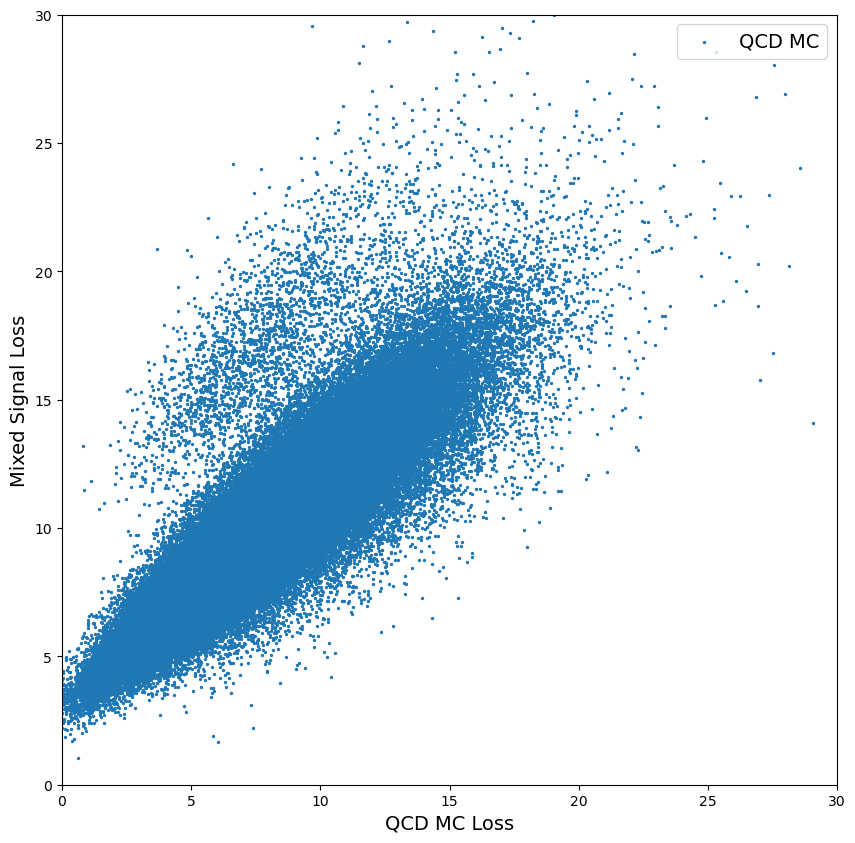

In [12]:
outDir = "evaluations/qcdbkg_massFlat/2017/quakSpaces/QCDBKG_massFlat_2017-Qstar2000_W400_UL17-and-Wp3000_B400_UL17-and-XYY_X3000_Y80_UL17/"
bkg_data = []
for i in range(3):
    with h5py.File(outDir+"eval_QCDBKG_{0}.h5".format(i),"r") as f:
        data = []
        data.append(f[bkg_axis][()][:,np.newaxis])
        data.append(f[sig_axis][()][:,np.newaxis])
        data = np.concatenate(data,axis=1)
        bkg_data.append(data)
bkg_data = np.concatenate(bkg_data,axis=0)

plt.figure(figsize=(10,10))
h1 = plt.scatter(bkg_data[:,0],bkg_data[:,1],s=2,label="QCD MC")
plt.xlabel("QCD MC Loss",fontsize=14)
plt.ylabel("Mixed Signal Loss",fontsize=14)
plt.xlim([0,30])
plt.ylim([0,30])
plt.legend(loc='upper right',fontsize=14)
plt.savefig(outDir+"scatter_qcdbkgOnly.pdf")